# CAV Methods Comparison: MeanDiff vs HCEP vs HCEP-Filtering vs Filtering

Comparison of four CAV approaches in the context of hierarchical concept relationships:

| Method | Description |
|---|---|
| **MeanDiff** | Standard CAV — difference of class means |
| **HCEP** | Orthogonalises child CAV w.r.t. parent direction |
| **HCEP-Filtering** | Two-stage inference: gate on B first, then score A with `(SV_A − SV_B)` |
| **Filtering** | Trains only on samples where parent = 1 |
| **Baseline** | Logistic regression on raw features — no CAV applied |

Analyses:
1. `|cos_sim(CAV_child, CAV_parent)|` — how entangled each method is with the parent
2. Projection ratio — how much of the parent direction remains in the child CAV
3. Effect of the co-occurrence threshold P(B|A) on cosine similarity
4. AUC comparison — standard, hard negatives, and no-CAV baseline


## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms as trn
import clip
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

from data_loading import load_sun_data
from dataloaders import create_sun_dataloader
from cav_utils import (
    calculate_centroid_cav,
    calculate_hcep_cav,
    calculate_filtered_cav,
    get_cosine_similarity,
    is_obs_in_concept,
    #is_obs_in_concept_hcep_filtering, ###
    projection_ratio,
    find_optimal_threshold_vectorized,
    PARENTS_THRESHOLDS
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


In [2]:
# Load dataset
df_sun, attributes_list, attr_cols = load_sun_data(
    base_path='data/SUN/SUNAttributeDB', threshold=0.5
)
y_labels = df_sun[attr_cols].values
print(f"Images: {len(df_sun)}  |  Attributes: {len(attr_cols)}")

# Load ResNet18-Places365
model_file = 'models/resnet18_places365.pth'
conv_model = models.resnet18(num_classes=365)
checkpoint  = torch.load(model_file, map_location=lambda s, l: s)
state_dict  = {k.replace('module.', ''): v for k, v in checkpoint['state_dict'].items()}
conv_model.load_state_dict(state_dict)
conv_model.fc = nn.Identity()
conv_model = conv_model.to(DEVICE).eval()

centre_crop = trn.Compose([
    trn.Resize((256, 256)), trn.CenterCrop(224), trn.ToTensor(),
    trn.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load CLIP ViT-B/32
clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()
print(f"CLIP embedding dim: {clip_model.visual.output_dim}")


Images: 14340  |  Attributes: 102
CLIP embedding dim: 512


In [3]:
# Feature extraction dataloaders
dl_resnet = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=centre_crop,
    attr_cols=attr_cols, batch_size=32, num_workers=4
)
dl_clip = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=clip_preprocess,
    attr_cols=attr_cols, batch_size=64, num_workers=4
)

# Extract ResNet18 features
feats_resnet = []
with torch.no_grad():
    for imgs, _, _ in tqdm(dl_resnet, desc="ResNet18 features"):
        feats_resnet.append(conv_model(imgs.to(DEVICE)).cpu().numpy())
X_resnet = np.concatenate(feats_resnet, axis=0)

# Extract CLIP features (L2-normalised)
feats_clip = []
with torch.no_grad():
    for imgs, _, _ in tqdm(dl_clip, desc="CLIP features"):
        f = clip_model.encode_image(imgs.to(DEVICE)).float()
        f = f / f.norm(dim=1, keepdim=True)
        feats_clip.append(f.cpu().numpy())
X_clip = np.concatenate(feats_clip, axis=0)

print(f"ResNet18: {X_resnet.shape}  |  CLIP: {X_clip.shape}")


ResNet18 features:   0%|          | 0/449 [00:00<?, ?it/s]

/home/JanTar/miniconda3/envs/automl/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv2d(input, weight, bias, self.stride,
CLIP features: 100%|██████████| 225/225 [02:39<00:00,  1.41it/s]


ResNet18: (14340, 512)  |  CLIP: (14340, 512)


In [4]:
# Hierarchical pairs: (child, parent)
all_pairs = [
    # empirical
    ('research',            'enclosed area'),
    ('camping',             'open area'),
    ('medical activity',    'enclosed area'),
    ('gaming',              'enclosed area'),
    ('sand',                'natural light'),
    ('carpet',              'enclosed area'),
    # semantic
    ('ocean',               'open area'),
    ('conducting business', 'working'),
    ('pavement',            'asphalt'),
    ('climbing',            'rock/stone'),
    ('rusty',               'aged/ worn'),
    ('ice',                 'cold'),
]

# Train / test split (consistent with other notebooks)
indices = np.arange(len(df_sun))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

df_meta       = df_sun[attr_cols].reset_index(drop=True)
df_train_meta = df_meta.iloc[train_idx].reset_index(drop=True)
df_test_meta  = df_meta.iloc[test_idx].reset_index(drop=True)

feature_sets = {
    "ResNet18": (X_resnet[train_idx], X_resnet[test_idx], X_resnet),
    "CLIP":     (X_clip[train_idx],   X_clip[test_idx],   X_clip),
}

# Colors for CAV methods (Baseline added separately in AUC section)
METHOD_COLORS = {
    "MeanDiff":       "#4C72B0",
    "HCEP":           "#DD8452",
    "HCEP-Filtering": "#55A868",
    "Filtering":      "#C44E52",
}
METHODS = list(METHOD_COLORS.keys())
print("Setup complete.")


Setup complete.


## 2. Compute CAVs for all methods and pairs

In [5]:
def calculate_hcep_filtering_cav(cav_child_md, cav_parent_md):
    """HCEP-Filtering: normalised difference (SV_A - SV_B).
    Orthogonal to SV_B when SV_B = proj(SV_A -> SV_B).
    """
    diff = cav_child_md - cav_parent_md
    norm = np.linalg.norm(diff)
    if norm < 1e-10:
        raise ValueError("SV_A - SV_B ≈ 0 — concepts may be identical")
    return diff / norm


def compute_all_cavs(features, df, pairs):
    """
    Returns a DataFrame with |cos_sim| and proj_ratio for all 4 methods
    and every (child, parent) pair.

    proj_ratio uses projection_ratio() from cav_utils:
        projection_ratio(cav, parent) = dot(cav, parent)²
    For normalised vectors this equals cos_sim².
    """
    records = []
    for child, parent in pairs:
        idx_cp = df.index[df[child]  == 1.0].tolist()
        idx_cn = df.index[df[child]  == 0.0].tolist()
        idx_pp = df.index[df[parent] == 1.0].tolist()
        idx_pn = df.index[df[parent] == 0.0].tolist()

        try:
            cav_parent  = calculate_centroid_cav(features, idx_pp, idx_pn)
            cav_md      = calculate_centroid_cav(features, idx_cp, idx_cn)
            cav_hcep    = calculate_hcep_cav(features, idx_cp, idx_cn, parent_cav=cav_parent)
            cav_hcep_f  = calculate_hcep_filtering_cav(cav_md, cav_parent)
            cav_filt    = calculate_filtered_cav(features, idx_cp, idx_cn, idx_pp)
        except ValueError as e:
            print(f"  [SKIPPED] {child}: {e}")
            continue

        for method, cav in [
            ("MeanDiff",       cav_md),
            ("HCEP",           cav_hcep),
            ("HCEP-Filtering", cav_hcep_f),
            ("Filtering",      cav_filt),
        ]:
            cs = get_cosine_similarity(cav, cav_parent)
            pr = projection_ratio(cav, cav_parent)
            records.append({
                "Child":       child,
                "Parent":      parent,
                "Method":      method,
                "cos_sim":     round(cs,  5),
                "abs_cos_sim": round(abs(cs), 5),
                "proj_ratio":  round(pr,  5),
            })
    return pd.DataFrame(records)


print("Computing CAVs...")
dfs_cav = {}
for model_name, (X_tr, X_te, X_full) in feature_sets.items():
    dfs_cav[model_name] = compute_all_cavs(X_full, df_meta, all_pairs)
    dfs_cav[model_name]["Model"] = model_name
    print(f"  {model_name}: {len(dfs_cav[model_name])} records")

df_cav_all = pd.concat(dfs_cav.values(), ignore_index=True)
print("Done.")

Computing CAVs...
  ResNet18: 48 records
  CLIP: 48 records
Done.


## 3

Obliczanie Hard Negatives AUC...


Hard AUC (CLIP):   0%|          | 0/12 [00:00<?, ?it/s]

Hard AUC (CLIP): 100%|██████████| 12/12 [00:00<00:00, 16.90it/s]


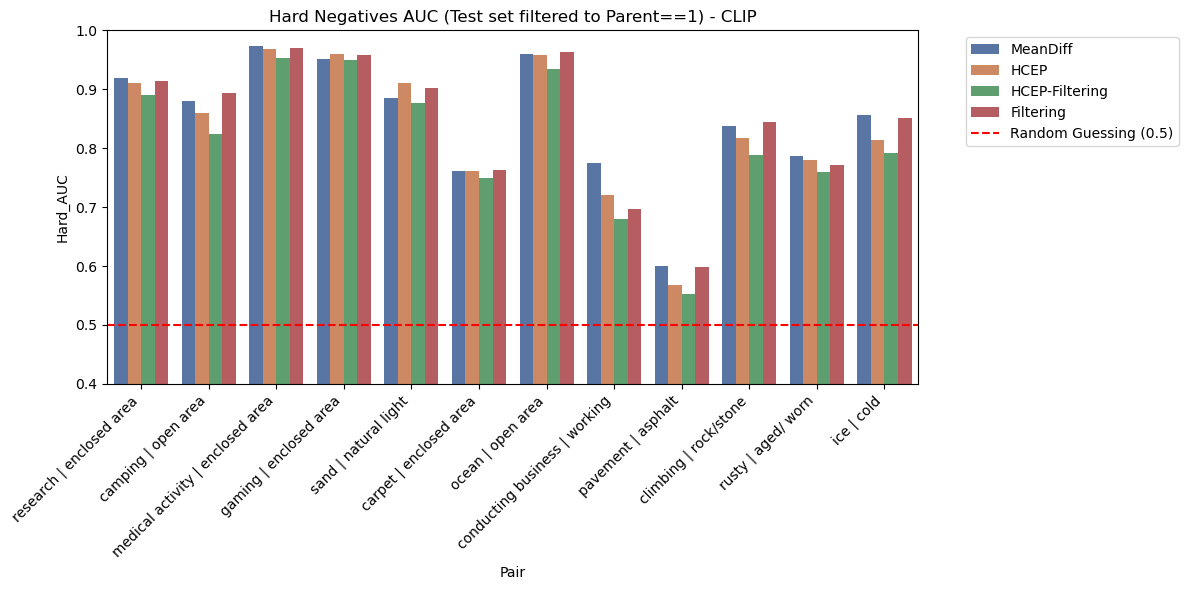

In [6]:
# ==========================================
# 1. HARD NEGATIVES AUC (Parent == 1 Subset)
# ==========================================
print("Obliczanie Hard Negatives AUC...")

records_hard_auc = []
model_name = "CLIP" # Skupmy się na jednym modelu dla czytelności, np. CLIP
X_tr, X_te, X_full = feature_sets[model_name]

for child, parent in tqdm(all_pairs, desc=f"Hard AUC ({model_name})"):
    # Indeksy do treningu CAV (na całym zbiorze treningowym)
    idx_cp = df_train_meta.index[df_train_meta[child] == 1.0].tolist()
    idx_cn = df_train_meta.index[df_train_meta[child] == 0.0].tolist()
    idx_pp = df_train_meta.index[df_train_meta[parent] == 1.0].tolist()
    idx_pn = df_train_meta.index[df_train_meta[parent] == 0.0].tolist()
    
    # Pomijamy jeśli brak wystarczającej liczby próbek
    if len(idx_cp) < 5 or len(idx_pp) < 5: continue
        
    try:
        cav_parent  = calculate_centroid_cav(X_tr, idx_pp, idx_pn)
        cav_md      = calculate_centroid_cav(X_tr, idx_cp, idx_cn)
        cav_hcep    = calculate_hcep_cav(X_tr, idx_cp, idx_cn, parent_cav=cav_parent)
        cav_hcep_f  = calculate_hcep_filtering_cav(cav_md, cav_parent)
        cav_filt    = calculate_filtered_cav(X_tr, idx_cp, idx_cn, idx_pp) # zakladam adaptację f-kcji
    except Exception as e:
        continue

    # Zbiór testowy: TYLKO obrazy, gdzie rodzic == 1 (Hard Negatives + True Positives)
    # Sprawdzamy czy wektor potrafi odróżnić dziecko od INNYCH dzieci tego samego rodzica
    test_parent_mask = df_test_meta[parent] == 1.0
    X_te_hard = X_te[test_parent_mask]
    y_te_hard = df_test_meta.loc[test_parent_mask, child].values
    
    # Jeśli w zbiorze testowym brakuje którejś z klas, pomijamy AUC
    if len(np.unique(y_te_hard)) < 2: continue

    cav_dict = {
        "MeanDiff": cav_md, "HCEP": cav_hcep, 
        "HCEP-Filtering": cav_hcep_f, "Filtering": cav_filt
    }
    
    for method, cav in cav_dict.items():
        if cav is None: continue
        projections = np.dot(X_te_hard, cav)
        auc = roc_auc_score(y_te_hard, projections)
        
        records_hard_auc.append({
            "Pair": f"{child} | {parent}",
            "Method": method,
            "Hard_AUC": auc
        })

df_hard_auc = pd.DataFrame(records_hard_auc)

# Wizualizacja Hard AUC
plt.figure(figsize=(12, 6))
sns.barplot(data=df_hard_auc, x='Pair', y='Hard_AUC', hue='Method', palette=METHOD_COLORS)
plt.axhline(0.5, color='red', linestyle='--', label='Random Guessing (0.5)')
plt.xticks(rotation=45, ha='right')
plt.title(f"Hard Negatives AUC (Test set filtered to Parent==1) - {model_name}")
plt.ylim(0.4, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4

In [ ]:
# ==========================================
# 2. INTRA-PARENT CONFUSION (FPR na rodzeństwie)
# ==========================================
print("Obliczanie False Positive Rate na rodzeństwie...")

# Grupowanie dzieci pod tym samym rodzicem
parent_to_children = {}
for c, p in all_pairs:
    parent_to_children.setdefault(p, []).append(c)

records_fpr = []

for parent, children in parent_to_children.items():
    if len(children) < 2: continue # Potrzebujemy co najmniej dwójki rodzeństwa
        
    for child in children:
        siblings = [c for c in children if c != child]
        
        # Obliczenie CAVs na TRAIN
        idx_cp = df_train_meta.index[df_train_meta[child] == 1.0].tolist()
        idx_cn = df_train_meta.index[df_train_meta[child] == 0.0].tolist()
        idx_pp = df_train_meta.index[df_train_meta[parent] == 1.0].tolist()
        idx_pn = df_train_meta.index[df_train_meta[parent] == 0.0].tolist()
        
        cav_parent = calculate_centroid_cav(X_tr, idx_pp, idx_pn)
        cav_md     = calculate_centroid_cav(X_tr, idx_cp, idx_cn)
        
        try:
            cav_filt = calculate_filtered_cav(X_tr, idx_cp, idx_cn, idx_pp)
        except ValueError:
            cav_filt = None
        
        # POPRAWKA 1: Funkcja zwraca tylko best_t, prawidłowa kolejność argumentów
        y_train_child = df_train_meta[child].values
        
        t_md = find_optimal_threshold_vectorized(X_tr, y_train_child, cav_md)
        if cav_filt is not None:
            t_filt = find_optimal_threshold_vectorized(X_tr, y_train_child, cav_filt)
        else:
            t_filt = 0.0
        
        # Testujemy FPR na zbiorze testowym, ale TYLKO na obrazach, gdzie rodzeństwo == 1, a dziecko == 0
        sibling_mask = df_test_meta[siblings].sum(axis=1) > 0 # występuje przynajmniej 1 rodzeństwo
        target_mask = df_test_meta[child] == 0.0 # ale nie występuje target
        eval_mask = sibling_mask & target_mask
        
        if eval_mask.sum() == 0: continue
            
        X_eval = X_te[eval_mask]
        
        # POPRAWKA 2: Bezpośrednie liczenie na macierzach (dużo szybsze, zamiast pętli przez is_obs_in_concept)
        # Normalizacja X_eval
        X_eval_norm = X_eval / (np.linalg.norm(X_eval, axis=1, keepdims=True) + 1e-10)
        
        # Predykcja dla MeanDiff
        cav_md_norm = cav_md.flatten() / (np.linalg.norm(cav_md) + 1e-10)
        sim_md = np.dot(X_eval_norm, cav_md_norm)
        pred_md = (sim_md >= t_md).astype(int)
        fpr_md = np.mean(pred_md)
        
        # Predykcja dla Filtering
        if cav_filt is not None:
            cav_filt_norm = cav_filt.flatten() / (np.linalg.norm(cav_filt) + 1e-10)
            sim_filt = np.dot(X_eval_norm, cav_filt_norm)
            pred_filt = (sim_filt >= t_filt).astype(int)
            fpr_filt = np.mean(pred_filt)
        else:
            fpr_filt = 0.0
        
        records_fpr.append({
            "Target Concept": child,
            "Parent": parent,
            "FPR MeanDiff": fpr_md,
            "FPR Filtering": fpr_filt
        })

df_fpr = pd.DataFrame(records_fpr)
if not df_fpr.empty:
    df_fpr_melt = df_fpr.melt(id_vars=['Target Concept', 'Parent'], value_vars=['FPR MeanDiff', 'FPR Filtering'], 
                              var_name='Method', value_name='False Positive Rate')

    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_fpr_melt, x='Target Concept', y='False Positive Rate', hue='Method', 
                palette={"FPR MeanDiff": METHOD_COLORS["MeanDiff"], "FPR Filtering": METHOD_COLORS["Filtering"]})
    plt.title("Sibling Confusion: Jak często wektor myli się na innych dzieciach tego samego rodzica?")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Zbyt mało relacji rodzeństwa (lub danych) do obliczenia FPR.")

Obliczanie False Positive Rate na rodzeństwie...


TypeError: cannot unpack non-iterable numpy.float64 object

## 5

Generowanie wizualizacji rozkładu rzutów 2D...


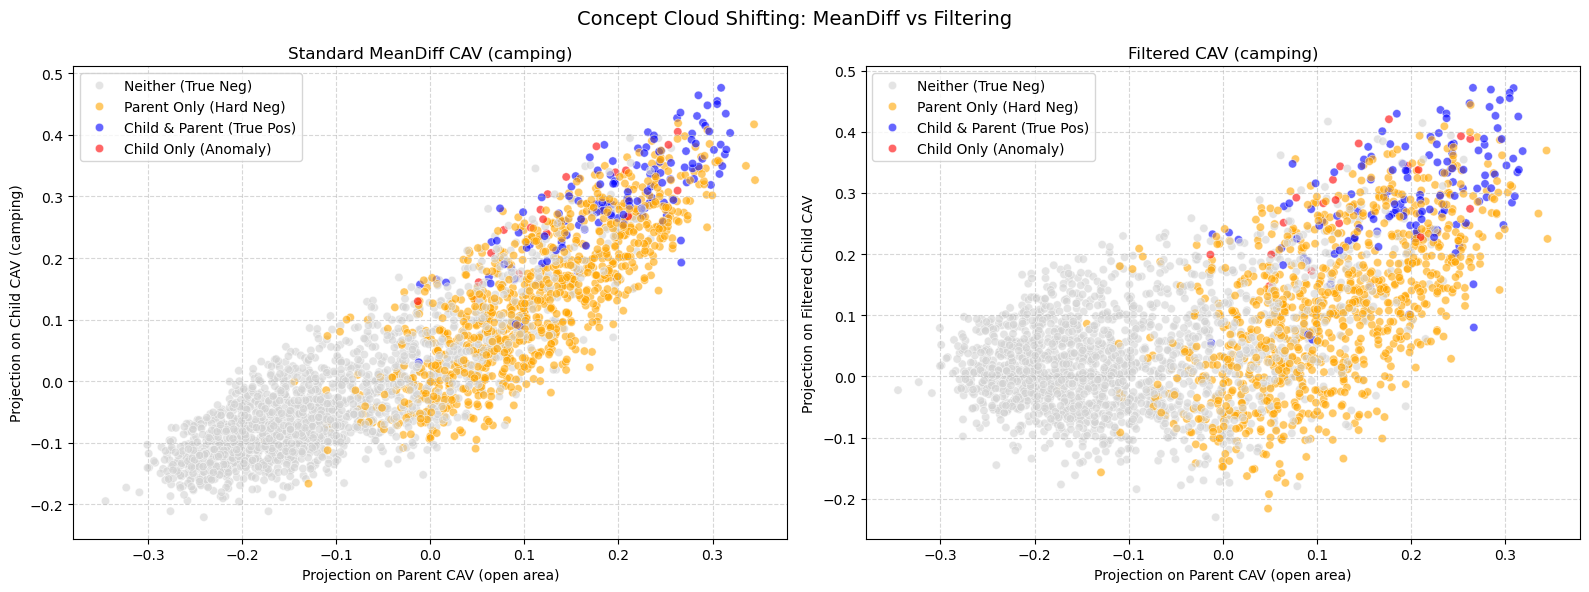

In [8]:
# ==========================================
# 3. WIZUALIZACJA PRZESTRZENI 2D
# ==========================================
print("Generowanie wizualizacji rozkładu rzutów 2D...")

# Wybierzmy jedną, konkretną parę do demonstracji
demo_child = 'camping'
demo_parent = 'open area'

idx_cp = df_train_meta.index[df_train_meta[demo_child] == 1.0].tolist()
idx_cn = df_train_meta.index[df_train_meta[demo_child] == 0.0].tolist()
idx_pp = df_train_meta.index[df_train_meta[demo_parent] == 1.0].tolist()
idx_pn = df_train_meta.index[df_train_meta[demo_parent] == 0.0].tolist()

cav_parent = calculate_centroid_cav(X_tr, idx_pp, idx_pn)
cav_md     = calculate_centroid_cav(X_tr, idx_cp, idx_cn)
cav_filt   = calculate_filtered_cav(X_tr, idx_cp, idx_cn, idx_pp)

# Rzuty na zbiorze testowym
proj_parent = np.dot(X_te, cav_parent)
proj_child_md = np.dot(X_te, cav_md)
proj_child_filt = np.dot(X_te, cav_filt)

# Kategoryzacja punktów dla ładnych kolorów na wykresie
y_c = df_test_meta[demo_child].values
y_p = df_test_meta[demo_parent].values

categories = []
for c, p in zip(y_c, y_p):
    if c == 1 and p == 1: categories.append('Child & Parent (True Pos)')
    elif c == 0 and p == 1: categories.append('Parent Only (Hard Neg)')
    elif c == 1 and p == 0: categories.append('Child Only (Anomaly)')
    else: categories.append('Neither (True Neg)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
palette_dict = {
    'Neither (True Neg)': 'lightgrey',
    'Parent Only (Hard Neg)': 'orange',
    'Child & Parent (True Pos)': 'blue',
    'Child Only (Anomaly)': 'red'
}

# Subplot 1: MeanDiff
sns.scatterplot(x=proj_parent, y=proj_child_md, hue=categories, palette=palette_dict, alpha=0.6, ax=ax1)
ax1.set_title(f"Standard MeanDiff CAV ({demo_child})")
ax1.set_xlabel(f"Projection on Parent CAV ({demo_parent})")
ax1.set_ylabel(f"Projection on Child CAV ({demo_child})")
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Filtering
sns.scatterplot(x=proj_parent, y=proj_child_filt, hue=categories, palette=palette_dict, alpha=0.6, ax=ax2)
ax2.set_title(f"Filtered CAV ({demo_child})")
ax2.set_xlabel(f"Projection on Parent CAV ({demo_parent})")
ax2.set_ylabel(f"Projection on Filtered Child CAV")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Concept Cloud Shifting: MeanDiff vs Filtering", fontsize=14)
plt.tight_layout()
plt.show()